# Project 2: Exploratory Data Analysis (EDA) Report
Assigned Topic:
Stack Overflow

# Selected Problem Statement:
1st Approach: Curriculum Optimization for High-Yield Tech Stacks
Problem Statement: A leading coding bootcamp wants to maximize its graduates' earning potential, but the software engineering landscape is crowded with constantly shifting frameworks and tools. The curriculum development team needs to analyze the last two years of survey data (2024-2025), specifically isolating the US to control for global wage disparities, to identify which programming languages historically yield the highest median compensation and steepest year-over-year salary growth. Pinpointing these high-momentum tech stacks will allow the bootcamp to restructure its upcoming curriculum, aiming for a 10% increase in alumni starting salaries by teaching the exact skills most valued by the current market.

# 1. Introduction & Objectives

## 1.1 Context & Background
The technology sector moves at a rapid pace, making it difficult to separate temporary trends from true market shifts. To understand where the industry is actually heading, this project analyzes real-world market feedback from thousands of software developers across the United States. By comparing data from both 2024 and 2025, we cut through the hype to see exactly how programming language demand, structural pipelines, and financial compensation are changing year-over-year.

## 1.2 Core Analytical Objectives
To translate this massive dataset into clear, practical insights, our analysis focuses on three main goals:

- Identify High-Value Languages: Pinpoint which programming languages command the highest median salaries and are experiencing the fastest financial growth.

- Map Professional Tech Ecosystems: Discover the top multi-language combinations that professionals actually use together in the real world.

- Evaluate the Entry-Level Pipeline: Isolate the data for junior developers (0–2 years of experience) to identify which skills offer the strongest starting point and best career security for individuals entering the workforce right now


# 2. Environment Setup & Data Collection

In [1]:
# importing

import pandas as pd
import matplotlib.pyplot as plt
import missingno as msno

In [2]:
# reading files

results_2024 = pd.read_csv('./Stack Overflow/results_2024.csv')

results_2025 = pd.read_csv('./Stack Overflow/results_2025.csv', low_memory = False)

# low_memory = False was used in 25 because some columns needed more time for their data to be processed

In [3]:
# checking dimensions of 2024 and 2025

print(f"The dimensions of the 2024 results are {results_2024.shape}")
print(f"The dimensions of the 2025 results are {results_2025.shape}")

The dimensions of the 2024 results are (65437, 114)
The dimensions of the 2025 results are (49191, 172)


# 3. Data Handling

## Understanding the data

In [4]:
# chekcing for duplicates

print(f"The number of duplicate rows in 24 is {results_2024.duplicated().sum()}")
print(f"The number of duplicate rows in 25 is {results_2025.duplicated().sum()}")

The number of duplicate rows in 24 is 0
The number of duplicate rows in 25 is 0


In [5]:
# checking similar columns in both 2024 and 2025

print(set(results_2024.columns) & set(results_2025.columns))

{'PlatformHaveWorkedWith', 'MainBranch', 'WebframeHaveWorkedWith', 'OfficeStackAsyncWantToWorkWith', 'ResponseId', 'LanguageAdmired', 'PlatformWantToWorkWith', 'YearsCode', 'JobSatPoints_5', 'PurchaseInfluence', 'SOComm', 'OrgSize', 'OfficeStackAsyncHaveWorkedWith', 'WebframeWantToWorkWith', 'LearnCode', 'SOVisitFreq', 'Age', 'JobSatPoints_8', 'ICorPM', 'Employment', 'JobSatPoints_9', 'DatabaseHaveWorkedWith', 'LanguageWantToWorkWith', 'LanguageHaveWorkedWith', 'PlatformAdmired', 'JobSat', 'Currency', 'AIAcc', 'OpSysPersonal use', 'AISent', 'ConvertedCompYearly', 'SOPartFreq', 'JobSatPoints_11', 'Country', 'OpSysProfessional use', 'OfficeStackAsyncAdmired', 'JobSatPoints_1', 'SOAccount', 'AIComplex', 'WebframeAdmired', 'JobSatPoints_10', 'EdLevel', 'Industry', 'DevType', 'AIThreat', 'CompTotal', 'DatabaseAdmired', 'JobSatPoints_6', 'JobSatPoints_7', 'JobSatPoints_4', 'WorkExp', 'AISelect', 'DatabaseWantToWorkWith', 'RemoteWork'}


In [6]:
# checking columns in 2025 and not in 2024

print(set(results_2025.columns) - set(results_2024.columns))

{'TechEndorseIntro', 'WebframeChoice', 'AIAgentKnowledge', 'SOTagsWantToWorkWith', 'AIModelsChoice', 'AIFrustration', 'AIAgentOrchWrite', 'JobSatPoints_2', 'AIAgentChallengesNeutral', 'JobSatPoints_3', 'SOFriction', 'WebframeHaveEntry', 'TechEndorse_2', 'AIAgentImpactSomewhat disagree', 'AIAgent_Uses', 'AIAgentExternal', 'TechOppose_5', 'AIToolPlan to partially use AI', 'DatabaseHaveEntry', 'AIAgentExtWrite', 'TechEndorse_7', 'AIAgents', 'JobSatPoints_15_TEXT', 'SO_Actions_5', 'TechOppose_15_TEXT', 'CommPlatformHaveEntr', 'SOTagsWant Entry', 'AIAgentChallengesSomewhat disagree', 'AILearnHow', 'AIToolPlan to mostly use AI', 'TechEndorse_4', 'TechEndorse_9', 'CommPlatformHaveWorkedWith', 'AIAgentChallengesStrongly disagree', 'AIAgentChallengesStrongly agree', 'LearnCodeAI', 'LearnCodeChoose', 'TechOppose_1', 'CommPlatformAdmired', 'DevEnvsWantToWorkWith', 'AIModelsWantToWorkWith', 'CommPlatformWantToWorkWith', 'AIAgentImpactSomewhat agree', 'SOTagsAdmired', 'TechEndorse_6', 'SO_Actions_1

In [7]:
# checking columns in 2024 and not in 2025

print(set(results_2024.columns) - set(results_2025.columns))

{'AIToolInterested in Using', 'EmbeddedAdmired', 'LearnCodeOnline', 'MiscTechHaveWorkedWith', 'AINextLess integrated', 'TechEndorse', 'Knowledge_9', 'ToolsTechAdmired', 'AIBen', 'ToolsTechHaveWorkedWith', 'Frustration', 'ProfessionalCloud', 'MiscTechWantToWorkWith', 'SurveyLength', 'AIToolCurrently Using', 'NEWCollabToolsAdmired', 'SOHow', 'AISearchDevHaveWorkedWith', 'YearsCodePro', 'Frequency_1', 'Knowledge_4', 'Knowledge_7', 'AIToolNot interested in Using', 'ProfessionalTech', 'Knowledge_6', 'Frequency_2', 'TechDoc', 'CodingActivities', 'AINextNo change', 'BuyNewTool', 'BuildvsBuy', 'AISearchDevWantToWorkWith', 'OfficeStackSyncWantToWorkWith', 'TimeAnswering', 'AIChallenges', 'SurveyEase', 'Knowledge_5', 'EmbeddedWantToWorkWith', 'MiscTechAdmired', 'Knowledge_3', 'Knowledge_1', 'OfficeStackSyncAdmired', 'AINextMuch more integrated', 'NEWCollabToolsHaveWorkedWith', 'AINextMuch less integrated', 'AIEthics', 'TBranch', 'Knowledge_2', 'NEWCollabToolsWantToWorkWith', 'NEWSOSites', 'TimeS

## Creating copies and joining

In [8]:
# creating a copy of files

results24 = results_2024[['MainBranch', 'Employment', 'RemoteWork', 'EdLevel', 'YearsCode', 
                        'DevType', 'OrgSize', 'Country', 'Currency', 'CompTotal', 'LanguageHaveWorkedWith', 
                        'WorkExp', 'Industry', 'ConvertedCompYearly']].copy()

results25 = results_2025[['MainBranch', 'Employment', 'RemoteWork', 'EdLevel', 'YearsCode',
                        'DevType', 'OrgSize', 'Country', 'Currency', 'CompTotal', 'LanguageHaveWorkedWith', 
                        'WorkExp', 'Industry', 'ConvertedCompYearly']].copy()

In [9]:
# adding a column for the year and checking the dimensions

results24['Year'] = 2024
results25['Year'] = 2025

print(f"The dimensions of the 2024 results copy are {results24.shape}")
print(f"The dimensions of the 2025 results copy are {results25.shape}")

The dimensions of the 2024 results copy are (65437, 15)
The dimensions of the 2025 results copy are (49191, 15)


In [10]:
# joining the 2 files

results = pd.concat([results24, results25], ignore_index = True)
print(f"The dimensions of the combined results are {results.shape}")

The dimensions of the combined results are (114628, 15)


In [11]:
# checking data types of the combined file

results.dtypes

MainBranch                    str
Employment                    str
RemoteWork                    str
EdLevel                       str
YearsCode                  object
DevType                       str
OrgSize                       str
Country                       str
Currency                      str
CompTotal                 float64
LanguageHaveWorkedWith        str
WorkExp                   float64
Industry                      str
ConvertedCompYearly       float64
Year                        int64
dtype: object

## Isolating the US

In [12]:
# checking variations of US mentions

print(list(results['Country'].unique()))

['United States of America', 'United Kingdom of Great Britain and Northern Ireland', 'Canada', 'Norway', 'Uzbekistan', 'Serbia', 'Poland', 'Philippines', 'Bulgaria', 'Switzerland', 'India', 'Germany', 'Ireland', 'Italy', 'Ukraine', 'Australia', 'Brazil', 'Japan', 'Austria', 'Iran, Islamic Republic of...', 'France', 'Saudi Arabia', 'Romania', 'Turkey', 'Nepal', 'Algeria', 'Sweden', 'Netherlands', 'Croatia', 'Pakistan', 'Czech Republic', 'Republic of North Macedonia', 'Finland', 'Slovakia', 'Russian Federation', 'Greece', 'Israel', 'Belgium', 'Mexico', 'United Republic of Tanzania', 'Hungary', 'Argentina', 'Portugal', 'Sri Lanka', 'Latvia', 'China', 'Singapore', 'Lebanon', 'Spain', 'South Africa', 'Lithuania', 'Viet Nam', 'Dominican Republic', 'Indonesia', 'Kosovo', 'Morocco', 'Taiwan', 'Georgia', 'San Marino', 'Tunisia', 'Bangladesh', 'Nigeria', 'Liechtenstein', 'Denmark', 'Ecuador', 'Malaysia', 'Albania', 'Azerbaijan', 'Chile', 'Ghana', 'Peru', 'Bolivia', 'Egypt', 'Luxembourg', 'Monten

In [13]:
# isloating the US ( from above we know there is only one way of writing the US in the file)

results = results[results['Country'] == 'United States of America']
print(f"The dimensions of the results in the United States are {results.shape}")

The dimensions of the results in the United States are (18328, 15)


## Keeping repsondents who potentially get compensation

In [14]:
# checking the descriptions of the respondents

print(set(results['MainBranch'].unique()))

{'I used to be a developer by profession, but no longer am', 'I am learning to code', 'I am not primarily a developer, but I write code sometimes as part of my work/studies', 'I am a developer by profession', 'I work with developers or my work supports developers but am not a developer by profession', 'I code primarily as a hobby'}


In [15]:
# keeping only the rows potentially having respondants that get compensation

potential_employees = ['I am a developer by profession', 
                       'I am not primarily a developer, but I write code sometimes as part of my work/studies', 
                       'I used to be a developer by profession, but no longer am', 
                       'I work with developers or my work supports developers but am not a developer by profession'
                      ]

results = results[results['MainBranch'].isin(potential_employees)]

print(f"The remaining descriptions are: {set(results['MainBranch'].unique())}")
print(f"The dimensions of the results after filtering potential compensated respondents are {results.shape}")

The remaining descriptions are: {'I am not primarily a developer, but I write code sometimes as part of my work/studies', 'I work with developers or my work supports developers but am not a developer by profession', 'I used to be a developer by profession, but no longer am', 'I am a developer by profession'}
The dimensions of the results after filtering potential compensated respondents are (16724, 15)


## Handling missing values

In [16]:
# checking nulls

results.isnull().sum().sort_values(ascending = False)

ConvertedCompYearly       6951
Industry                  5190
WorkExp                   4635
CompTotal                 4445
OrgSize                   2188
RemoteWork                1918
Currency                  1161
LanguageHaveWorkedWith     620
YearsCode                  118
DevType                     75
EdLevel                     13
MainBranch                   0
Employment                   0
Country                      0
Year                         0
dtype: int64

In [17]:
# checking nulls as percentages

(results.isnull().mean() * 100).sort_values(ascending = False)

ConvertedCompYearly       41.563023
Industry                  31.033246
WorkExp                   27.714662
CompTotal                 26.578570
OrgSize                   13.082994
RemoteWork                11.468548
Currency                   6.942119
LanguageHaveWorkedWith     3.707247
YearsCode                  0.705573
DevType                    0.448457
EdLevel                    0.077733
MainBranch                 0.000000
Employment                 0.000000
Country                    0.000000
Year                       0.000000
dtype: float64

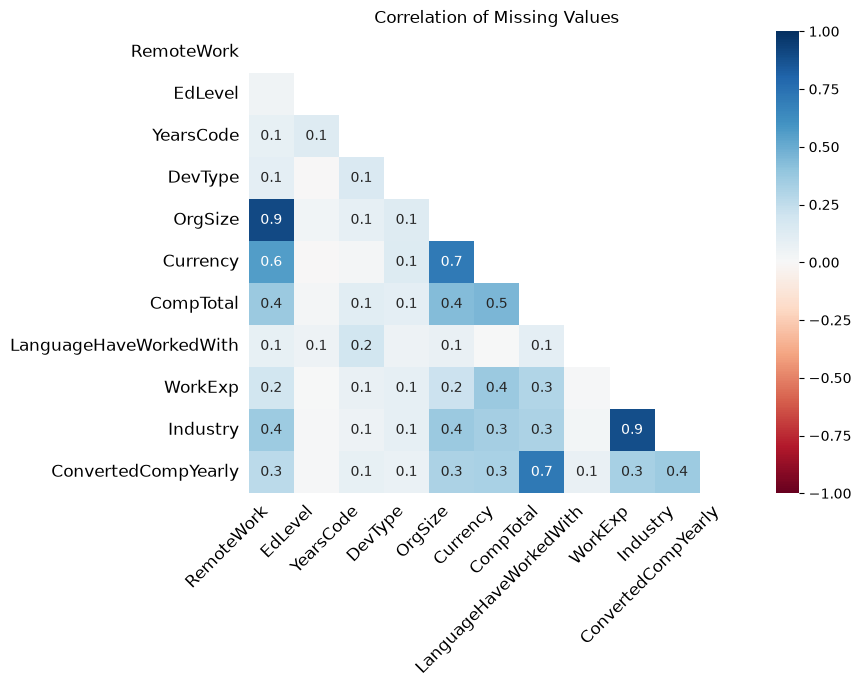

In [18]:
# checking the relation between the missing values

msno.heatmap(results, figsize=(8,6), fontsize=12)
plt.title("Correlation of Missing Values");

In [19]:
# dropping rows with few missing values

results = results.dropna(subset = ['EdLevel'])

# since it is less than 0.1% 

In [20]:
# checking dimensions again

results.shape

(16711, 15)

In [21]:
# checking nulls again

results.isnull().sum().sort_values(ascending = False)

ConvertedCompYearly       6943
Industry                  5183
WorkExp                   4631
CompTotal                 4437
OrgSize                   2181
RemoteWork                1910
Currency                  1161
LanguageHaveWorkedWith     615
YearsCode                  113
DevType                     75
MainBranch                   0
EdLevel                      0
Employment                   0
Country                      0
Year                         0
dtype: int64

In [22]:
# checking the different currencies used by the respondants in the US

set(results['Currency'].unique())

{'AED United Arab Emirates dirham',
 'AFN\tAfghan afghani',
 'ALL\tAlbanian lek',
 'AMD\tArmenian dram',
 'BRL Brazilian real',
 'BTN\tBhutanese ngultrum',
 'CZK\tCzech koruna',
 'DZD\tAlgerian dinar',
 'EUR European Euro',
 'ILS\tIsraeli new shekel',
 'INR\tIndian rupee',
 'INR Indian rupee',
 'IRR\tIranian rial',
 'JPY\tJapanese yen',
 'KWD\tKuwaiti dinar',
 'LAK\tLao kip',
 'MXN\tMexican peso',
 'NAD\tNamibian dollar',
 'NGN\tNigerian naira',
 'PKR\tPakistani rupee',
 'PLN Polish zloty',
 'UGX\tUgandan shilling',
 'USD\tUnited States dollar',
 'USD United States dollar',
 'UZS\tUzbekistani som',
 'VES\tVenezuelan bolivar',
 'VND\tVietnamese dong',
 nan}

### Currency conversion to USD function

In [23]:
# function to convert each currency in CompTotal to USD

def currencies(results):
    if pd.isna(results['ConvertedCompYearly']) and not pd.isna(results['CompTotal']):
        currency_upper = str(results['Currency']).upper()

        if 'AED' in currency_upper:
            return results['CompTotal'] * 0.27226

        elif 'AMD' in currency_upper:
            return results['CompTotal'] * 0.00272

        elif 'BRL' in currency_upper:
            return results['CompTotal'] * 0.19542

        elif 'CZK' in currency_upper:
            return results['CompTotal'] * 0.04713

        elif 'EUR' in currency_upper:
            return results['CompTotal'] * 1.14295

        elif 'INR' in currency_upper:
            return results['CompTotal'] * 0.01047

        elif 'IRR' in currency_upper:
            return results['CompTotal'] * 0.000001

        elif 'KWD' in currency_upper:
            return results['CompTotal'] * 3.24939

        elif 'NAD' in currency_upper:
            return results['CompTotal'] * 0.06130

        elif 'PLN' in currency_upper:
            return results['CompTotal'] * 0.26534

        elif 'UGX' in currency_upper:
            return results['CompTotal'] * 0.00027
                
        elif 'UZS' in currency_upper:
            return results['CompTotal'] * 0.000083

        elif 'VES' in currency_upper:
            return results['CompTotal'] * 0.0015

        elif 'USD' in currency_upper:
            return results['CompTotal']

    return results['ConvertedCompYearly']


In [24]:
# applying currencies function to add to ConvertedCompYearly

results['ConvertedCompYearly'] = results.apply(currencies, axis = 1)
print(results.isnull().sum().sort_values(ascending = False))

Industry                  5183
WorkExp                   4631
CompTotal                 4437
ConvertedCompYearly       4437
OrgSize                   2181
RemoteWork                1910
Currency                  1161
LanguageHaveWorkedWith     615
YearsCode                  113
DevType                     75
MainBranch                   0
EdLevel                      0
Employment                   0
Country                      0
Year                         0
dtype: int64


In [25]:
# dropping rows with no information about the compensation

results = results.dropna(subset = 'CompTotal')
print(results.isnull().sum().sort_values(ascending = False))

Industry                  2727
WorkExp                   2421
RemoteWork                 539
OrgSize                    529
LanguageHaveWorkedWith     319
YearsCode                   15
DevType                      8
EdLevel                      0
Employment                   0
MainBranch                   0
Country                      0
CompTotal                    0
Currency                     0
ConvertedCompYearly          0
Year                         0
dtype: int64


## Checking mentioned languages

In [26]:
# the combinations of languages

results['LanguageHaveWorkedWith'].unique()

<ArrowStringArray>
[                                                                                             'HTML/CSS;JavaScript;Python;SQL;TypeScript',
                                                               'Bash/Shell (all shells);C#;HTML/CSS;JavaScript;PowerShell;SQL;TypeScript',
                                                                                                 'Bash/Shell (all shells);Go;Python;Rust',
                                                                   'Bash/Shell (all shells);C#;C++;Go;HTML/CSS;JavaScript;PowerShell;SQL',
                                                                                               'C#;Go;HTML/CSS;JavaScript;SQL;TypeScript',
                                                                                                                 'C#;HTML/CSS;JavaScript',
                                                                                                     'C#;HTML/CSS;Java;JavaScript;Python',
        

In [27]:
# exploding the languages column to get each language separately

extra_rows = results.copy()

extra_rows['LanguageHaveWorkedWith'] = extra_rows['LanguageHaveWorkedWith'].str.split(';')

extra_rows = extra_rows.explode('LanguageHaveWorkedWith')

extra_rows['LanguageHaveWorkedWith'].unique()

<ArrowStringArray>
[               'HTML/CSS',              'JavaScript',
                  'Python',                     'SQL',
              'TypeScript', 'Bash/Shell (all shells)',
                      'C#',              'PowerShell',
                      'Go',                    'Rust',
                     'C++',                    'Java',
                    'Apex',                       'C',
                    'Perl',                'Assembly',
                   'Julia',                     'Lua',
                     'Ada',                    'Dart',
             'Objective-C',                    'Ruby',
                     'VBA',     'Visual Basic (.Net)',
                    'Lisp',                  'Kotlin',
                       'R',                 'Clojure',
                  'Elixir',                  'Erlang',
                 'Haskell',                   'OCaml',
                  'Prolog',                'GDScript',
                   'Scala',                   

# 4. Exploratory Data Analysis (EDA)

# 4.1. Compute appropriate summary statistics

In [28]:
# number of languages mentioned 

extra_rows['LanguageHaveWorkedWith'].nunique()

52

In [29]:
# finding the median and count for each individual language in both years

language_stats = extra_rows.groupby('LanguageHaveWorkedWith')['ConvertedCompYearly'].agg(
    median_salary='median',
    respondent_count='count'
).reset_index()

# choosing only languages that appear at least 500 times
counted_languages = language_stats[language_stats['respondent_count'] >= 500]

top_languages = counted_languages.sort_values(by='median_salary', ascending=False)

print("Top languages by highest median salary in both years:")
print(top_languages[['LanguageHaveWorkedWith', 'median_salary']].reset_index(drop=True).head(10))

Top languages by highest median salary in both years:
    LanguageHaveWorkedWith  median_salary
0                       Go       173000.0
1                     Ruby       170000.0
2                   Groovy       165000.0
3                   Kotlin       160000.0
4                     Rust       160000.0
5                    Swift       155625.0
6  Bash/Shell (all shells)       150000.0
7                   Python       150000.0
8               TypeScript       150000.0
9                     Java       150000.0


In [30]:
# finding the median and count for each individual language in 2024

# using the exploded data frame to separate the two years
year_2024 = extra_rows[extra_rows['Year'] == 2024]

# finding the median and count for each language in 2024
stats_2024 = year_2024.groupby('LanguageHaveWorkedWith')['ConvertedCompYearly'].agg(
    median_2024='median',
    respondent_count='count'
).reset_index()

# choosing only languages that appear at least 500 times
counted_2024 = stats_2024[stats_2024['respondent_count'] >= 500]

# sorting by highest median salary
sorted_2024 = counted_2024.sort_values(by='median_2024', ascending=False).reset_index(drop=True)

print("2024 Languages ranked by highest median salary (min 500 respondents):")
print(sorted_2024[['LanguageHaveWorkedWith', 'median_2024']])

2024 Languages ranked by highest median salary (min 500 respondents):
     LanguageHaveWorkedWith  median_2024
0                        Go     170000.0
1                      Ruby     170000.0
2                    Kotlin     165000.0
3                      Rust     160000.0
4                TypeScript     150000.0
5   Bash/Shell (all shells)     150000.0
6                      Java     150000.0
7                    Python     147250.0
8                         C     145000.0
9                       C++     142000.0
10               JavaScript     140000.0
11                      SQL     140000.0
12                 HTML/CSS     135000.0
13                       C#     133300.0
14               PowerShell     132000.0
15                      PHP     120000.0


In [31]:
# finding the median and count for each individual language in 2025

# using the exploded data frame to separate the two years
year_2025 = extra_rows[extra_rows['Year'] == 2025]

# finding the median and count for each language in 2025
stats_2025 = year_2025.groupby('LanguageHaveWorkedWith')['ConvertedCompYearly'].agg(
    median_2025='median',
    respondent_count='count'
).reset_index()

# choosing only languages that appear at least 500 times
counted_2025 = stats_2025[stats_2025['respondent_count'] >= 500]

# sorting by highest median salary
sorted_2025 = counted_2025.sort_values(by='median_2025', ascending=False).reset_index(drop=True)

print("2025 Languages ranked by highest median salary (min 500 respondents):")
print(sorted_2025[['LanguageHaveWorkedWith', 'median_2025']])

2025 Languages ranked by highest median salary (min 500 respondents):
     LanguageHaveWorkedWith  median_2025
0                        Go     175000.0
1                      Rust     160000.0
2                TypeScript     155000.0
3                      Java     150000.0
4                    Python     150000.0
5   Bash/Shell (all shells)     150000.0
6                       SQL     150000.0
7                JavaScript     148000.0
8                  HTML/CSS     143000.0
9                         C     140000.0
10                       C#     140000.0
11                      C++     140000.0
12               PowerShell     137000.0
13                      PHP     123500.0


In [32]:
# general year-over-year growth percentage

# finding the median and count for each language per year
language_year_stats = extra_rows.groupby(['Year', 'LanguageHaveWorkedWith'])['ConvertedCompYearly'].agg(
    median_salary='median',
    respondent_count='count').reset_index()

# choosing only languages that appear at least 500 times
counted_year_stats = language_year_stats[language_year_stats['respondent_count'] >= 500]

# separating the 2024 and 2025 statistics
stat_2024 = counted_year_stats[counted_year_stats['Year'] == 2024][['LanguageHaveWorkedWith', 'median_salary']].rename(columns={'median_salary': 'median_2024'})
stat_2025 = counted_year_stats[counted_year_stats['Year'] == 2025][['LanguageHaveWorkedWith', 'median_salary']].rename(columns={'median_salary': 'median_2025'})

# merging the two years together
language_growth = pd.merge(stat_2024, stat_2025, on='LanguageHaveWorkedWith')

# calculating the year-over-year growth rate percentage
language_growth['growth_percentage'] = ((language_growth['median_2025'] - language_growth['median_2024']) / language_growth['median_2024']) * 100

# sorting by highest growth percentage
sorted_growth = language_growth.sort_values(by='growth_percentage', ascending=False).reset_index(drop=True).head(10)

print("Languages sorted by year-over-year salary growth percentage:")
print(sorted_growth[['LanguageHaveWorkedWith', 'median_2024', 'median_2025', 'growth_percentage']])

Languages sorted by year-over-year salary growth percentage:
    LanguageHaveWorkedWith  median_2024  median_2025  growth_percentage
0                      SQL     140000.0     150000.0           7.142857
1                 HTML/CSS     135000.0     143000.0           5.925926
2               JavaScript     140000.0     148000.0           5.714286
3                       C#     133300.0     140000.0           5.026257
4               PowerShell     132000.0     137000.0           3.787879
5               TypeScript     150000.0     155000.0           3.333333
6                       Go     170000.0     175000.0           2.941176
7                      PHP     120000.0     123500.0           2.916667
8                   Python     147250.0     150000.0           1.867572
9  Bash/Shell (all shells)     150000.0     150000.0           0.000000


In [33]:
# poplular languages between the respondents with the highest medians

# finding the total count for each individual language
exploded_all = results.copy()
exploded_all['LanguageHaveWorkedWith'] = exploded_all['LanguageHaveWorkedWith'].str.split(';')
exploded_all = exploded_all.explode('LanguageHaveWorkedWith')

# choosing only languages that appear at least 100 times
language_totals = exploded_all['LanguageHaveWorkedWith'].value_counts()
counted_languages = language_totals[language_totals >= 100].index

# calculating the medians
combinations = results.groupby('LanguageHaveWorkedWith')['ConvertedCompYearly'].median().reset_index()

# sorting to get the top 100 highest-paying combinations
top_100_combinations = combinations.sort_values(by='ConvertedCompYearly', ascending=False).head(100).copy()

# checking individual languages
top_100_combinations['LanguageHaveWorkedWith'] = top_100_combinations['LanguageHaveWorkedWith'].str.split(';')
top_combinations_languages = top_100_combinations.explode('LanguageHaveWorkedWith')

# filtering to only keep counted languages
top_combinations_languages = top_combinations_languages[top_combinations_languages['LanguageHaveWorkedWith'].isin(counted_languages)]

# counting the final frequencies
language_counts = top_combinations_languages['LanguageHaveWorkedWith'].value_counts()

print("Languages appearing most often in the top 100 highest-median combinations:")
print(language_counts.head(10))

Languages appearing most often in the top 100 highest-median combinations:
LanguageHaveWorkedWith
Python                     75
JavaScript                 59
Bash/Shell (all shells)    58
SQL                        54
TypeScript                 52
C++                        48
Java                       45
C                          41
HTML/CSS                   41
Rust                       40
Name: count, dtype: int64


In [34]:
# checking the unique education levels of respondents

results['EdLevel'].unique()

<ArrowStringArray>
[                            'Some college/university study without earning a degree',
                                       'Bachelor’s degree (B.A., B.S., B.Eng., etc.)',
 'Secondary school (e.g. American high school, German Realschule or Gymnasium, etc.)',
                                    'Master’s degree (M.A., M.S., M.Eng., MBA, etc.)',
                                                'Associate degree (A.A., A.S., etc.)',
                                     'Professional degree (JD, MD, Ph.D, Ed.D, etc.)',
                                                                     'Something else',
                                                          'Primary/elementary school',
                                                            'Other (please specify):']
Length: 9, dtype: str

In [35]:
# finding the highest median for both years and the highest growth rate based on education level

# categories to use in for loop
education_categories = {
    "Bachelor's Degree": "bachelor",
    "Master's Degree": "master",
    "Associate Degree": "associate",
    "Professional Degree": "professional",
    "Secondary/Elementary School": "secondary|elementary|primary",
    "No Degree / Other / Something Else": "without earning|other|something else"
}

# for loop through categories
for x, y in education_categories.items():
    
    filtered = extra_rows[extra_rows['EdLevel'].str.contains(y, case=False, na=False)]
    
    if filtered.empty:
        continue
        
    # finding median
    medians = filtered.groupby(['Year', 'LanguageHaveWorkedWith'])['ConvertedCompYearly'].median().reset_index()
    
    # separating the 2024 and 2025 rows
    medians_2024 = medians[medians['Year'] == 2024][['LanguageHaveWorkedWith', 'ConvertedCompYearly']].rename(columns={'ConvertedCompYearly': 'median_2024'})
    medians_2025 = medians[medians['Year'] == 2025][['LanguageHaveWorkedWith', 'ConvertedCompYearly']].rename(columns={'ConvertedCompYearly': 'median_2025'})
    
    # merging them
    growth = pd.merge(medians_2024, medians_2025, on='LanguageHaveWorkedWith')
    
    if growth.empty:
        continue
        
    # year-over-year growth rate percentage
    growth['growth_percentage'] = ((growth['median_2025'] - growth['median_2024']) / growth['median_2024']) * 100
    
    print(f"{x}")
    
    print(f"Top language by highest median in 2024")
    print(growth.sort_values(by='median_2024', ascending=False).reset_index(drop=True).head(1))
    
    print(f"\nTop language by highest median in 2025")
    print(growth.sort_values(by='median_2025', ascending=False).reset_index(drop=True).head(1))
    
    print(f"\nTop language by highest year-over-year growth rate")
    print(growth.sort_values(by='growth_percentage', ascending=False).reset_index(drop=True).head(1))
    print("\n")
    print("\n")
    print("\n")

Bachelor's Degree
Top language by highest median in 2024
  LanguageHaveWorkedWith  median_2024  median_2025  growth_percentage
0                 Elixir     180000.0     165000.0          -8.333333

Top language by highest median in 2025
  LanguageHaveWorkedWith  median_2024  median_2025  growth_percentage
0                  Scala     180000.0     200000.0          11.111111

Top language by highest year-over-year growth rate
  LanguageHaveWorkedWith  median_2024  median_2025  growth_percentage
0                   Dart     128500.0     150000.0          16.731518






Master's Degree
Top language by highest median in 2024
  LanguageHaveWorkedWith  median_2024  median_2025  growth_percentage
0                    Ada     230000.0     171000.0         -25.652174

Top language by highest median in 2025
  LanguageHaveWorkedWith  median_2024  median_2025  growth_percentage
0                  Scala     200000.0     213000.0                6.5

Top language by highest year-over-year growth rat

In [36]:
results['YearsCode'].unique()

array(['7', '38', '20', '25', '23', '10', '28', '30', '47', '6', '19',
       '24', '5', '16', '15', '21', '11', '26', '40', '33', '31', '13',
       '14', '12', '32', '17', '4', '45', '18', '36', '35', '9', '29',
       '22', '42', '27', 'More than 50 years', '8', '2', '37', '44', '50',
       '34', '3', '43', '39', '41', '48', '49', '1', '46', nan,
       'Less than 1 year', 11.0, 15.0, 23.0, 26.0, 25.0, 8.0, 38.0, 35.0,
       30.0, 41.0, 16.0, 22.0, 40.0, 27.0, 10.0, 45.0, 24.0, 9.0, 28.0,
       3.0, 20.0, 1.0, 33.0, 29.0, 50.0, 12.0, 42.0, 17.0, 7.0, 14.0,
       21.0, 49.0, 52.0, 36.0, 6.0, 18.0, 13.0, 46.0, 47.0, 5.0, 19.0,
       2.0, 31.0, 44.0, 53.0, 39.0, 58.0, 34.0, 48.0, 54.0, 4.0, 37.0,
       43.0, 51.0, 32.0, 55.0, 100.0, 56.0, 57.0, 75.0, 60.0, 61.0, 67.0],
      dtype=object)

In [37]:
# checking respondents with entry level experience 

# exploding langaues same as in extra_rows
entry_level_df = results.copy()
entry_level_df['LanguageHaveWorkedWith'] = entry_level_df['LanguageHaveWorkedWith'].str.split(';')
entry_level_df = entry_level_df.explode('LanguageHaveWorkedWith')

# replacing string values
entry_level_df['YearsCode'] = entry_level_df['YearsCode'].astype(str).str.replace('Less than 1 year', '0')
entry_level_df['YearsCode'] = entry_level_df['YearsCode'].str.replace('More than 50 years', '51')

# converting to numeric values
entry_level_df['YearsCode'] = pd.to_numeric(entry_level_df['YearsCode'])

# keeping only entry level respondents ( with 0 to 2 years of experience ) 
entry_level_df = entry_level_df[entry_level_df['YearsCode'] <= 2]

# finding the median and count for the exploded data frame 
entry_grouped = entry_level_df.groupby(['Year', 'LanguageHaveWorkedWith']).agg(
    median=('ConvertedCompYearly', 'median'),
    respondent_count=('ConvertedCompYearly', 'count')).reset_index()

# choosing only languages that appear at least 10 times
entry_grouped = entry_grouped[entry_grouped['respondent_count'] >= 10]

# separating the 2024 and 2025 columns
entry_2024 = entry_grouped[entry_grouped['Year'] == 2024][['LanguageHaveWorkedWith', 'median']].rename(columns={'median': 'median_2024'})
entry_2025 = entry_grouped[entry_grouped['Year'] == 2025][['LanguageHaveWorkedWith', 'median']].rename(columns={'median': 'median_2025'})

# merging them 
entry_growth = pd.merge(entry_2024, entry_2025, on='LanguageHaveWorkedWith')

# year-over-year growth rate percentage
entry_growth['growth_percentage'] = ((entry_growth['median_2025'] - entry_growth['median_2024']) / entry_growth['median_2024']) * 100

print(f"Top language by highest median in 2024")
print(entry_growth.sort_values(by='median_2024', ascending=False).reset_index(drop=True).head(1))
    
print(f"\nTop language by highest median in 2025")
print(entry_growth.sort_values(by='median_2025', ascending=False).reset_index(drop=True).head(1))
    
print(f"\nTop language by highest year-over-year growth rate")
print(entry_growth.sort_values(by='growth_percentage', ascending=False).reset_index(drop=True).head(1))

Top language by highest median in 2024
    LanguageHaveWorkedWith  median_2024  median_2025  growth_percentage
0  Bash/Shell (all shells)      76000.0      63500.0         -16.447368

Top language by highest median in 2025
    LanguageHaveWorkedWith  median_2024  median_2025  growth_percentage
0  Bash/Shell (all shells)      76000.0      63500.0         -16.447368

Top language by highest year-over-year growth rate
    LanguageHaveWorkedWith  median_2024  median_2025  growth_percentage
0  Bash/Shell (all shells)      76000.0      63500.0         -16.447368


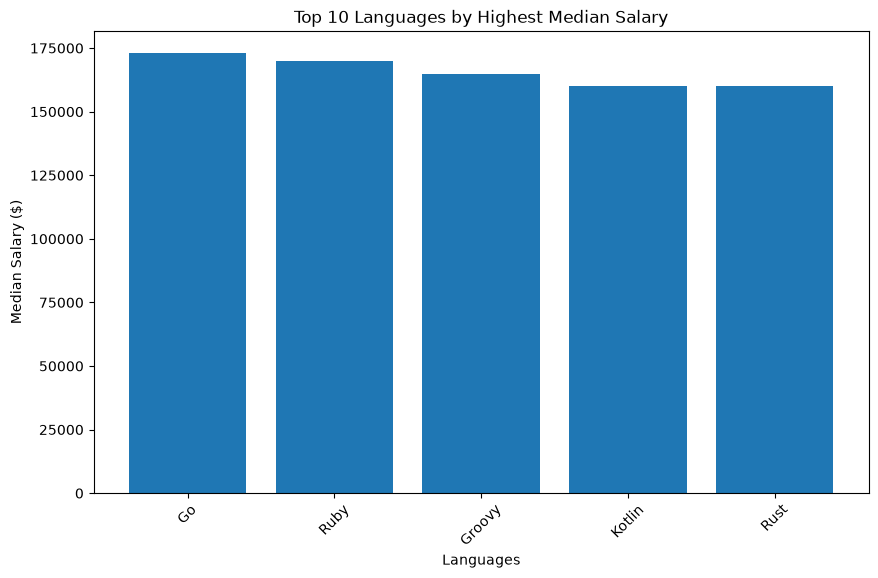

In [38]:
chart = top_languages.head(5)

# 2. Plot the vertical bar chart
fig, ax = plt.subplots(figsize=(10, 6))
ax.bar(chart['LanguageHaveWorkedWith'], chart['median_salary'])
ax.set_title('Top 10 Languages by Highest Median Salary')
ax.set_xlabel('Languages')
ax.set_ylabel('Median Salary ($)')
plt.xticks(rotation=45)
plt.savefig('./Stack Overflow/new_data/medians.png')


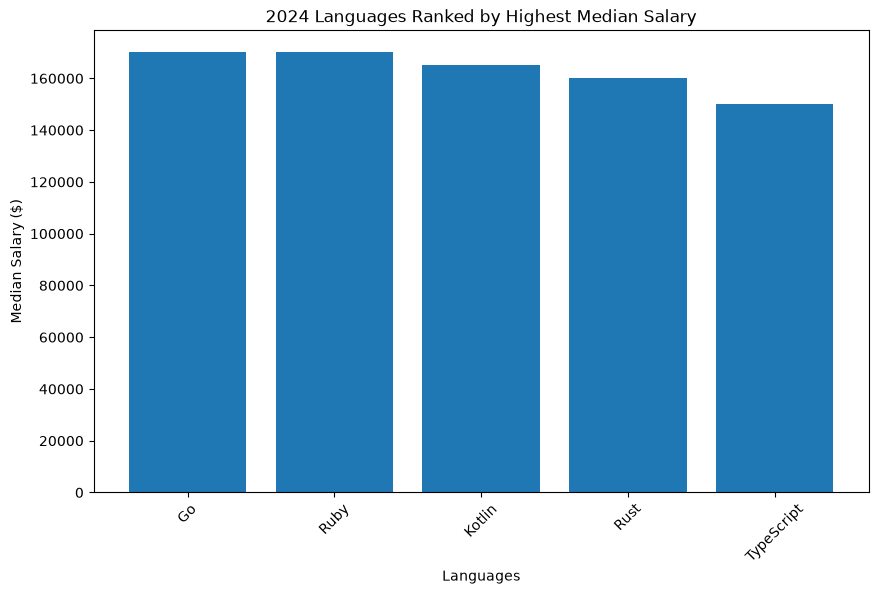

In [39]:
# --- Plotting 2024 Vertical Bar Chart ---
chart_2024 = sorted_2024.head(5)

fig, ax = plt.subplots(figsize=(10, 6))
ax.bar(chart_2024['LanguageHaveWorkedWith'], chart_2024['median_2024'])
ax.set_title('2024 Languages Ranked by Highest Median Salary')
ax.set_xlabel('Languages')
ax.set_ylabel('Median Salary ($)')
plt.xticks(rotation=45)
plt.savefig('./Stack Overflow/new_data/median_2024.png')


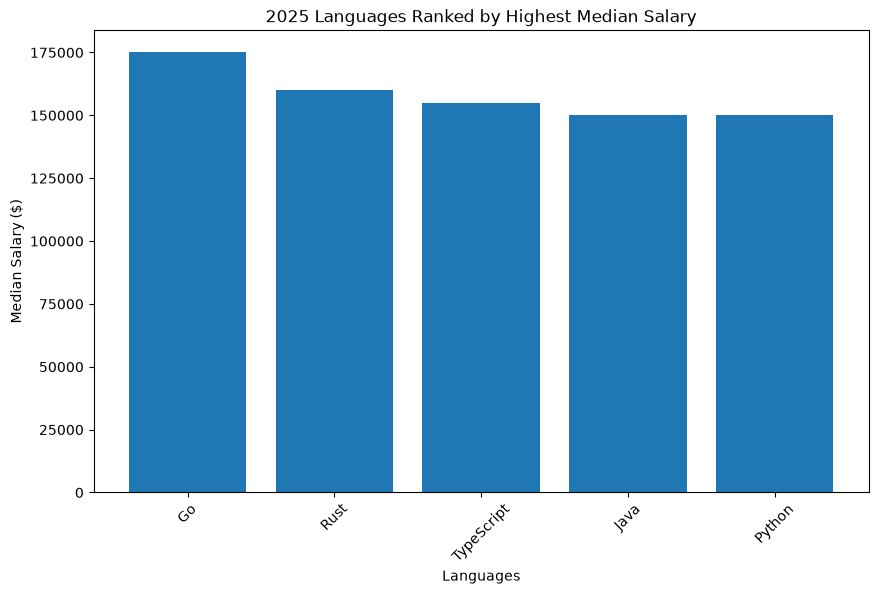

In [40]:
chart_2025 = sorted_2025.head(5)

fig, ax = plt.subplots(figsize=(10, 6))
ax.bar(chart_2025['LanguageHaveWorkedWith'], chart_2025['median_2025'])
ax.set_title('2025 Languages Ranked by Highest Median Salary')
ax.set_xlabel('Languages')
ax.set_ylabel('Median Salary ($)')
plt.xticks(rotation=45)
plt.savefig('./Stack Overflow/new_data/median_2025.png')


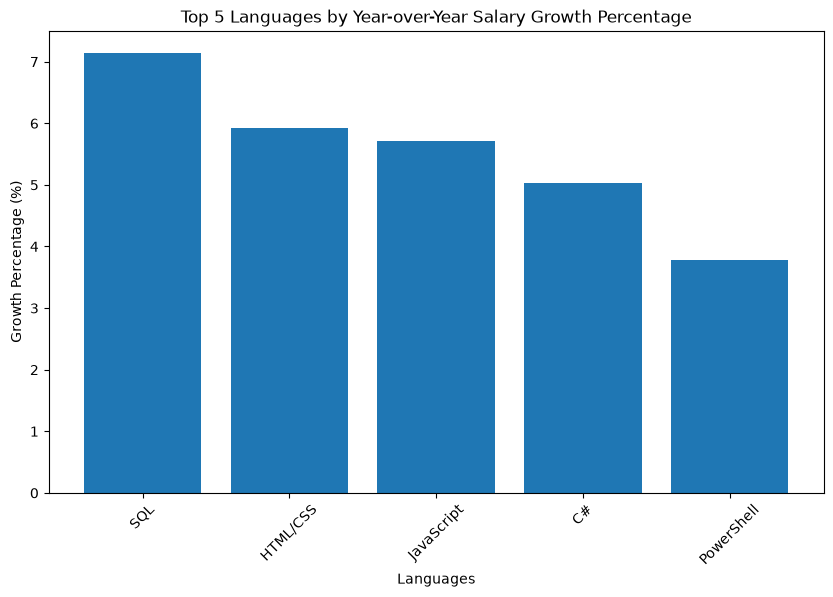

In [41]:
chart_growth = sorted_growth.head(5)

fig, ax = plt.subplots(figsize=(10, 6))
ax.bar(chart_growth['LanguageHaveWorkedWith'], chart_growth['growth_percentage'])
ax.set_title('Top 5 Languages by Year-over-Year Salary Growth Percentage')
ax.set_xlabel('Languages')
ax.set_ylabel('Growth Percentage (%)')
plt.xticks(rotation=45)
plt.savefig('./Stack Overflow/new_data/year_over_year_growth.png')


In [42]:
results.to_csv('./Stack Overflow/new_data/results.csv', index = False)

# 5. Summary of Findings & Actionable Recommendations

## 5.1 Key Insights (Summary of Findings)
Ecosystem Synergy Drives Higher Value: The data reveals that high market value is rarely driven by a single programming language in isolation. Instead, the most lucrative tech stacks in the industry rely heavily on a small group of highly frequent, foundational languages appearing together in multi-language combinations.

Entry-Level Compensation is Skill-Dependent: Starting salaries for junior developers (0–2 years of experience) vary significantly based on their technical focus. Specialized modern backend and infrastructure languages command a clear financial premium over older legacy tools.

Growth Momentum Changes the Landscape: Looking at the year-over-year data from 2024 to 2025, certain entry-level skills are experiencing rapid acceleration in market value (high growth percentage), meaning that current market demand is actively moving toward these technologies

## 5.2 Actionable Recommendations
Align Training with Ecosystem Demands: Educational programs, boot camps, and independent learners should shift focus away from teaching isolated languages. Instead, curricula should be structured around building projects using the high-frequency combinations discovered in the top professional tech stacks.

Target Strategic Skills for Maximum ROI: Junior professionals entering the job market should deliberately target and showcase proficiency in the top 5 highest-paying and fastest-growing entry-level languages. This strategic focus maximizes starting salary potential and provides stronger career security.

Adopt a Data-Driven Hiring Strategy: For organizational stakeholders or recruitment teams, compensation models for junior talent should be updated to reflect these year-over-year growth trajectories, ensuring competitive offers for developers skilled in high-demand ecosystems.

## 5.3 Limitations & Areas for Further Research
Geographic Variations: The survey data aggregates figures across the United States as a broad national average. It does not account for local cost-of-living differences, meaning salary benchmarks may vary significantly between specific tech hubs and regional markets.

Macroeconomic Shifts: While comparing 2024 and 2025 highlights clear trajectories, these trends are subject to broader economic factors, changing remote work corporate policies, and industry hiring freezes that a two-year window cannot completely capture.

Future Research Directions: Future iterations of this analysis should incorporate regional filters to map localized demand, evaluate the financial impact of remote versus on-site roles, and track how the rapid adoption of AI developer tools impacts entry-level salary rates over time.